In [1]:
import copy

import numpy as np
import pandas as pd
import seaborn as sns

from reinforcement_learning.agent import EpsilonGreedyAgent
from reinforcement_learning.action import Action
from reinforcement_learning.action_selection import UCB

In [3]:
n_runs = 100
n_steps_per_run = 1000
rewards_per_run_per_agent = [[], []]

for irun in range(n_runs):
    actions = [Action.gaussian(0, 1) for i in range(10)]
    agents = [EpsilonGreedyAgent(*actions, action_selection_method=UCB(2)),
              EpsilonGreedyAgent(*actions, epsilon=0.1)]
    for i, agent in enumerate(agents):
        # print(agent.optimal_action)
        rewards_per_step = []
        for istep in range(n_steps_per_run):
            agent.act()
            rewards_per_step.append(agent.mean_reward)
            # print(agent.reward_estimates)
        rewards_per_run_per_agent[i].append(rewards_per_step)
rewards_per_run_per_agent = np.array(rewards_per_run_per_agent)

In [4]:
mean_reward_per_agent = np.mean(rewards_per_run_per_agent, axis=1)

In [5]:
reward_df = pd.DataFrame({'mean_reward': mean_reward_per_agent.reshape(-1),
                          'action_selection': pd.Categorical([a for action_selection in ['UCB', 'epsilon-greedy'] for a in [action_selection] * n_steps_per_run]),
                          'step': [i for _ in range(2) for i in range(n_steps_per_run)]})

<Axes: xlabel='step', ylabel='mean_reward'>

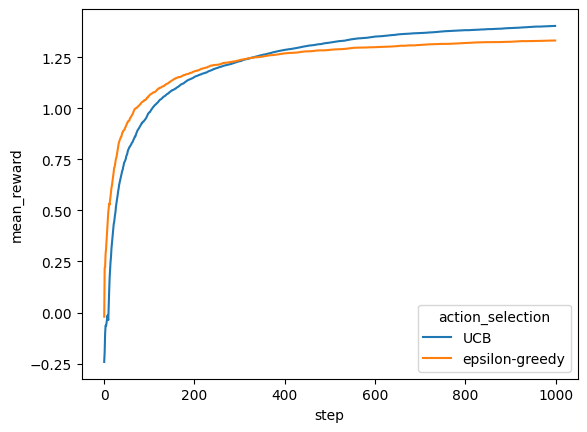

In [6]:
sns.lineplot(reward_df, x='step', y='mean_reward', hue='action_selection')